# **Homework 2: Securing the "AutoDrive" Firmware Pipeline**










**Integrantes:** Giselle Cevallos (00325549), Esteban Silva (00329204), Nicolas Soria (00326990)





**Scenario:** You are a Security Engineer at *AutoDrive*, a company that manages thousands of self-driving cars. You must ensure that when the company sends a software update (firmware) to a car, it is genuine, hasn't been tampered with, and cannot be intercepted by competitors.

### **Part 1: RSA Key Generation (The Mechanics)**
Before a car leaves the factory, it generates its own RSA key pair to communicate securely with AutoDrive HQ.

1.  **-Manual Calculation:** Assume a simplified RSA setup where the car chooses two small primes: $p = 11$ and $q = 13$.
    * Generate the public and private keys
    * Verify that they can be used for encryption and decryption


Para el calculo manual de las claves RSA utilizamos los numeros primos dados y los utilizamos para calcular n (modulo) .

Como sabemos los numeros primos son utilizados porque hacen complicado el proceso de ruptura de cifrado. Aun asi estos numeros son seleccionados  mediante una prueba de primalidad. Estos son algoritmos que encuentran eficientemente números primos para el cifrado, como la prueba de primalidad de Ranbin-Miller. Los números primos deben ser grandes y estar relativamente alejados entre sí para dificultar el descifrado de las claves.

n es el modulo del sistema  El módulo (mod) es una operación de módulo que significa el resto que queda después de dividir un lado o número por el otro.Podemos calcularlo por medio del producto de los números primos. Este producto forma parte tanto de la clave pública como de la clave privada.

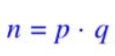

Calculamos para nuestro caso y sustituimos en los numeros primos dados:

n = 11 * 13
n = 143

Calculamos la phi de Euler o la función totiente de Euler. Funcion por la cual contaremos numeros primos con n para poder calcular la clave privada. Para ello utilizamos la formula:

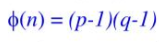

φ(n) = (p−1)(q−1)

φ(n) = 10×12

φ(n) = 120

El siguiente paso es elejir la clave publica. Elijimos el exponente de cifrado e , de tal manera que
1 < e < Φ(n), y
mcd(e, Φ(n)) = 1, es decir, e debe ser coprimo con Φ(n).




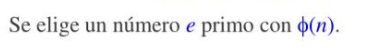


En nuestro caso seria elejir un numero que sea menor que 120 y coprimo con 120.

1 < 7 < 120

En este caso escojemos el e = 7  ya que 7 y 120 no comparten divisores

Ahora calcularemos la clave privada (d) o Calcular el exponente de descifrado d el cual se lo define como:

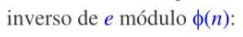

o

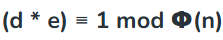

Es decir, d es el inverso multiplicativo modular de e mod Φ(n)

Podemos tener múltiples valores de d que satisfagan (d * e) ≡ 1 mod Φ(n), pero no importa qué valor elijamos, ya que todos ellos son claves válidas y darán como resultado el mismo mensaje al descifrarlo.

Estamos buscando el número
𝑑 que permitirá desencriptar lo que se cifró con 𝑒

Entonces necesitamos encontrar d tal que:

d * e  ≡  1 (mod 120)

d * 7  ≡  1 (mod 120)


Entonces empezamos a probar valores y convertimos la congruencia modular en una ecuación normal





d * 7 ≡ 1 (mod 120)

7d = 1 + 120k (transforacion)

d = 1 + 120k​ / 7







Prueba de valores de K desde el 1

k = 1 → d = (1 + 120(1)) / 7 = 121 / 7 = 17.28

k = 2 → d = (1 + 120(2)) / 7 = 241 / 7 = 34.42

k = 3 → d = (1 + 120(3)) / 7 = 361 / 7 = 51.57

k = 4 → d = (1 + 120(4)) / 7 = 481 / 7 = 68.71

k = 5 → d = (1 + 120(5)) / 7 = 601 / 7 = 85.85

k = 6 → d = (1 + 120(6)) / 7 = 721 / 7 = 103

Entonces podriamos usar como d = 130 como clave privada

Damos a conocer nuestra clave publica:

Clave pública: (n, e) = (143, 7)

Ocultamos nuestra clave privada:

Clave privada: (n, d) = (143, 103)



Y ocultamos los restantes valores como p, q y φ(n)

2.  **Implementation Logic:** Why is it computationally impossible for a hacker to find $d$ if they only know $n$ and $e$ in a real-world 2048-bit system?


Para veridicar que funciona hacemos una validacion cifrando y decifrando el mensaje

Supongamos que un usuario B desea enviarnos el mensaje "RSA".


Primero localiza nuestra clave publica:

Clave pública: (n, e) = (143, 7)



B escribe el mensaje a enviar como un numero menor que 149 y primo con el.

Puede considerar la siguiente representacion de letras por numeros (sin la ñ )

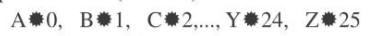

Y emplear la base 26 para representar cualquier palabra

Para nuestro mensaje: "RSA" usamos lo siguiente

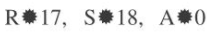

El mensaje seria por ende

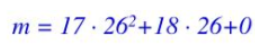



m = 11960

Como el mensaje debe ser menor a 143 debemos trabajar por bloques

R → 17

S → 18

A → 0

Ciframos cada letra con

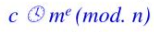

c = m^e mod n

R → 17

c = 17^7 mod 143 =3 0

S → 18

c = 18^7 mod 143 = 83

A → 0

c = 0^7 mod 143 = 0

Mensaje cifrado: (30, 83, 0)

**Desifrado:**

Usamos:

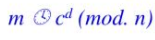

**30**

30^103 mod 143 = 17 ⇒ R

**83**

83^103 mod 143 = 18 ⇒ S

**0**

0^103 mod 143 = 0 ⇒ A


**Mensaje recuperado:** RSA

### **Part 2: Cryptographic Hashes (Integrity Check)**
The firmware file is 2GB. We don't want to sign the entire file because it is too slow.

1.  **The Avalanche Effect:** If you change exactly **one bit** in the 2GB firmware file and run it through SHA-256 again, how much of the resulting hash should change? Why is this property important for detecting a "Man-in-the-Middle" attack?


En SHA-256 existe una propiedad conocida como efecto avalancha, que significa que un cambio mínimo en el archivo, incluso de un solo bit dentro de un firmware de 2GB, genera un cambio completamente distinto en el hash resultante, afectando aproximadamente la mitad de sus bits. En la práctica esto quiere decir que el nuevo hash no tendrá ninguna relación visible con el original. Esta característica es muy importante para la seguridad, ya que permite detectar fácilmente si alguien ha modificado el archivo durante la transmisión, como en un ataque Man-in-the-Middle, porque cualquier alteración, por pequeña que sea, producirá un hash totalmente diferente y evidenciará la manipulación.

2.  **Collision Resistance:** Explain what a "Collision" is in hashing. If a hacker finds a way to make a malicious "Virus.bin" have the same SHA-256 hash as the "Update.bin," why does this break the entire security of the car?

Una colisión ocurre cuando dos archivos diferentes generan exactamente el mismo hash, algo que en teoría es posible pero extremadamente difícil en funciones seguras como SHA-256. Si un atacante lograra crear un archivo malicioso que tenga el mismo hash que el firmware original, el sistema no tendría forma de distinguir entre ambos y aceptaría el archivo falso como si fuera legítimo. Esto rompe completamente la seguridad del sistema, ya que la verificación de integridad dejaría de ser confiable, permitiendo que se ejecute código malicioso sin ser detectado. Por eso, la resistencia a colisiones es una propiedad clave para garantizar la seguridad en este tipo de sistemas.

### **Part 3: Digital Certificates (The Chain of Trust)**
AutoDrive HQ doesn't just send its public key to the car via a text file; it uses a **Digital Certificate**.

1.  **Research Task:** Research the **Certificate Signing Request (CSR)** process. List the four main pieces of information that AutoDrive HQ must send to a Certificate Authority (CA) to get a signed X.509 certificate.

Un CRS es un archivo que AutoDrive HQ genera y envía a una Autoridad Calificadora para solicitar un certificado digital X.509 firmado.

Este se compone de cuatro partes de información que AutoDrive HQ debe enviar.

- Una clave pública, la cual aparece dentro del certificado y que el vehículo va a usar para verificar las firmas o establecer una comunicación segura.

- Un nombre común que identifica el servidor o dominio para el cual se emite el certificado.

- La información de identidad de la organización, como el nombre de la organización, unidad organizacional,
ciudad o localidad,provincia o estado, país.

- La prueba de posesión de la clave privada para demostrar que AutoDrive HQ realmente posee la clave privada asociada a esa clave pública.

2.  **Validation:** When the car receives the HQ's certificate, it needs to verify it. What specific "Root Certificate" must be pre-installed on the car's computer at the factory for this to work?

Cuando el vehículo recibe el certificado de HQ, se debe comprobar si el certificado viene de una fuente confiable; en este caso, el vehículo tiene que tener preinstalado en fábrica un Root Certificate de la autoridad certificadora que firmó el certificado de AutoDrive HQ.

Este certificado actúa como raíz de confianza; entonces, cuando el carro recibe el certificado de HQ, se revisa si la cadena de certificados llega hasta una raíz que ya confía. Si llega a esta raíz confiable, entonces acepta el certificado como válido.

### **Part 4: Digital Signatures (Authentication)**
To prove the update is official, AutoDrive HQ "signs" the update.

1.  **The Workflow:** Describe the process of creating the signature.
    * What is hashed?
    * Which key (HQ Public or HQ Private) is used to encrypt the hash?

El proceso digital funciona de la siguiente manera:

  1. Autodrive HQ calcula el hash del archivo de firmware, se aplica una funcion hash, como SHA-256 al archivo de actualizacion.

  2. HQ firma ese hash con su clave privada, se firma el hash del archivo para que sea mas eficiente.

  3. El vehículo recibe el firmware y la firma digital, luego el carro calcula por su cuenta el hash del archivo recibido.

  4. El vehículo verifica la firma con la clave pública de HQ, si esta es valida y el hash calculado por el vehículo coincide con el original, entonces el archivo es auténtico y no fue alterado.

  | Paso | Acción | Resultado |
|---|---|---|
| 1 | HQ calcula el hash del firmware | Se obtiene una huella digital única del archivo |
| 2 | HQ firma el hash con su clave privada | Se genera la firma digital |
| 3 | El vehículo recibe el firmware y la firma | El vehículo calcula nuevamente el hash |
| 4 | El vehículo verifica la firma con la clave pública | Confirma autenticidad e integridad del archivo |



2.  **Non-Repudiation:** If a faulty update causes a car to crash, AutoDrive might try to claim they never sent that specific update. How does the use of a **Digital Signature** provide legal "Non-repudiation" in this case?

La firma digital proporciona no repudio porque solo AutoDrive HQ tiene la clave privada usada para firmar la actualización.
En este caso, si una versión del firmware contiene una firma válida que puede verificarse con la clave pública de HQ, existe la evidencia criptográfica de que HQ autorizó exactamente esa actualización.
Por lo tanto, la empresa no puede negar posteriormente haber enviado o aprobado esa versión.

### **Part 5: System Design Challenge**
**The Task:** Design a "Secure Update Protocol" for the car. Draw a flow diagram or provide a numbered list showing the interaction between **AutoDrive HQ** and the **Vehicle**.

Your design must use a **Hybrid System** (Asymmetric for keys, Symmetric for the 2GB file) and satisfy these five requirements:

| Requirement | How your design achieves it |
| :--- | :--- |
| **1. Secure Key Exchange** | How does the car get the AES "Session Key" from HQ? |
| **2. Confidentiality** | How do you ensure a competitor cannot "sniff" the firmware code? |
| **3. Integrity** | How does the car know the file wasn't corrupted during the download? |
| **4. Authentication** | How does the car know the update is from HQ and not a "Spoofed" server? |
| **5. Non-Repudiation** | How do we prove HQ is the one who authorized this specific version? |

1. Secure key change: HQ genera una clave de sesión AES-256 aleatoria y luego la cifra utilizando la clave pública RSA del vehículo antes de enviarla. Solo la clave privada del vehículo puede descifrarla. Un competidor que intercepte la transmisión no podrá leer la clave de sesión.

2. Confidentiality: El archivo de firmware de 2 GB se cifra utilizando esa clave de sesión AES mediante AES-256-GCM. Se utiliza cifrado simétrico porque es mucho más eficiente que RSA para grandes volúmenes de datos; usar RSA para 2 GB sería imprácticamente lento.

3. Integrity: HQ calcula un hash SHA-256 del firmware en texto plano y lo envía junto con el archivo cifrado. Después de descifrarlo, el vehículo vuelve a calcular el hash y lo compara. Cualquier byte corrupto producirá un hash completamente distinto, lo que hará que la actualización se cancele.

4. Authentication: HQ firma el hash utilizando su clave privada RSA. El vehículo verifica la firma con la clave pública de HQ, que fue preinstalada en fábrica. Incluso si un servidor falso envía un firmware aparentemente válido, no podrá falsificar la firma sin la clave privada de HQ.

5. Non-repudiation: HQ emite un manifiesto firmado que contiene el número de versión, la marca de tiempo y el hash del firmware. El vehículo almacena este manifiesto firmado en el dispositivo. Si surge alguna disputa sobre qué versión fue autorizada y cuándo, el manifiesto firmado proporciona una prueba criptográfica: HQ no puede negar posteriormente haberla publicado.

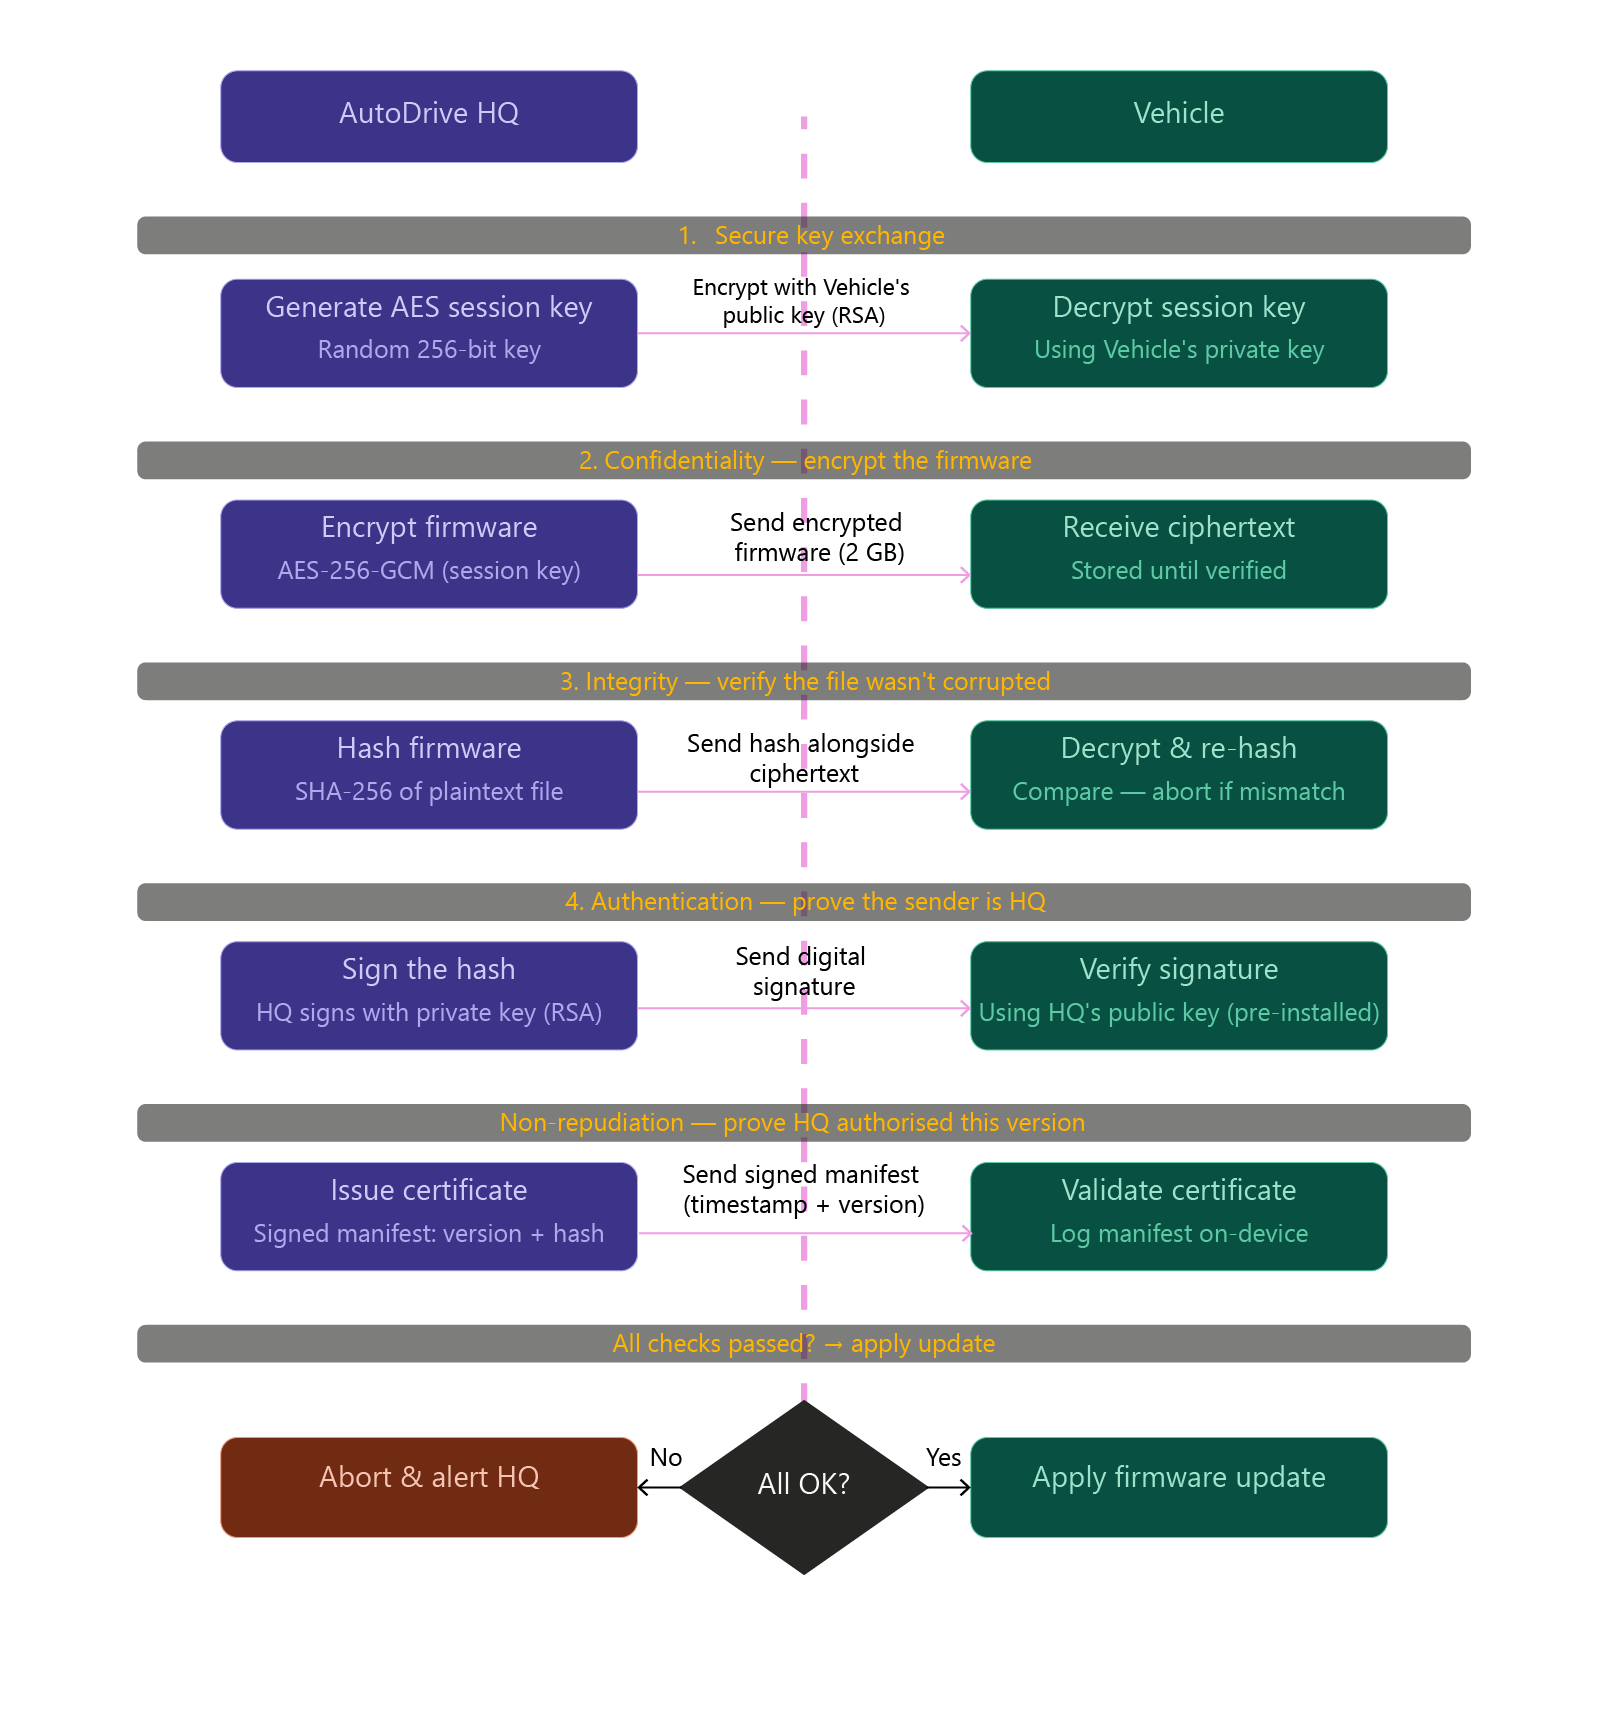

### Referencias:

https://www.geeksforgeeks.org/computer-networks/rsa-algorithm-cryptography/

https://www.cohesity.com/glossary/rsa-encryption/

https://www.slideserve.com/ash/criptograf-a-de-clave-p-blica

NIST. (2015). FIPS PUB 180-4: Secure Hash Standard (SHS). National Institute of Standards and Technology.

Stallings, W. (2017). Cryptography and Network Security: Principles and Practice. Pearson.